### Panel 5x3 using graph-tool

`functions_gt` have everything we need (besides plot settings, defined below).

In [3]:
from functions_gt import *

In [4]:
# Plot settings
import matplotlib
import matplotlib.pyplot as plt
matplotlib.rcParams.update({'text.usetex': True}) # LaTeX capabilities
matplotlib.rcParams.update({'text.latex.preamble': r"", "font.serif": "Times"})
matplotlib.rcParams.update({'font.family':'serif'})
get_ipython().run_line_magic('matplotlib', 'inline')
get_ipython().run_line_magic('config', "InlineBackend.figure_format = 'svg' # render figures in SVG")

the following is used for the "for-loops" of the plot.

In [25]:
def gen_graph_type(graph_type, N):
    """generates the graph we want"""
    if graph_type == "ER":
        return gt_edges(gt_er(N=N,kavg=10))
    elif graph_type == "BA":
        return gt_edges(gt_ba(N=N,m=5))
    elif graph_type == "SBM_eta_0.1":
        return gen_SBM_set(N=N,kavg=10,B=2,eta=.1)[0]
    elif graph_type == "SBM_eta_0.5":
        return gen_SBM_set(N=N,kavg=10,B=2,eta=.5)[0]
    elif graph_type == "SBM_eta_0.9":
        return gen_SBM_set(N=N,kavg=10,B=2,eta=.9)[0]
 
def sim_measure(sim_name):
    """calls the similarity measure"""
    if sim_name == 'NMI':
        return graphNMI
    elif sim_name == 'DC-NMI':
        return graphDCNMI
    elif sim_name == 'Jaccard':
        return jaccard
    elif sim_name == 'MesoB2':
        return mesoNMI
    elif sim_name == 'MesoB10':
        return mesoNMI
    elif sim_name == 'MesoB100':
        return mesoNMI

<br>

### panel with trivial partition, i.e., group membership $b_i = 0$ for all nodes $i$.

<br>

***WARNING***: sometimes it may happen that the noise attack will disconnect the network to the point of removing nodes from the graph object `g`. if that happens oftenly, one may want to manually control the final number of nodes in the graph after the attack.


ER

attacking ER with noise typeI . . .
computing graphNMI . . .
computing graphDCNMI . . .
computing jaccard . . .
computing mesoNMI . . .
computing mesoNMI . . .
computing mesoNMI . . .
attacking ER with noise typeII . . .
computing graphNMI . . .
computing graphDCNMI . . .
computing jaccard . . .
computing mesoNMI . . .
computing mesoNMI . . .
computing mesoNMI . . .
attacking ER with noise typeIII. . .
computing graphNMI . . .
computing graphDCNMI . . .
computing jaccard . . .
computing mesoNMI . . .
computing mesoNMI . . .
computing mesoNMI . . .

BA

attacking BA with noise typeI . . .
computing graphNMI . . .
computing graphDCNMI . . .
computing jaccard . . .
computing mesoNMI . . .
computing mesoNMI . . .
computing mesoNMI . . .
attacking BA with noise typeII . . .
computing graphNMI . . .
computing graphDCNMI . . .
computing jaccard . . .
computing mesoNMI . . .
computing mesoNMI . . .
computing mesoNMI . . .
attacking BA with noise typeIII. . .
computing graphNMI . . .
compu

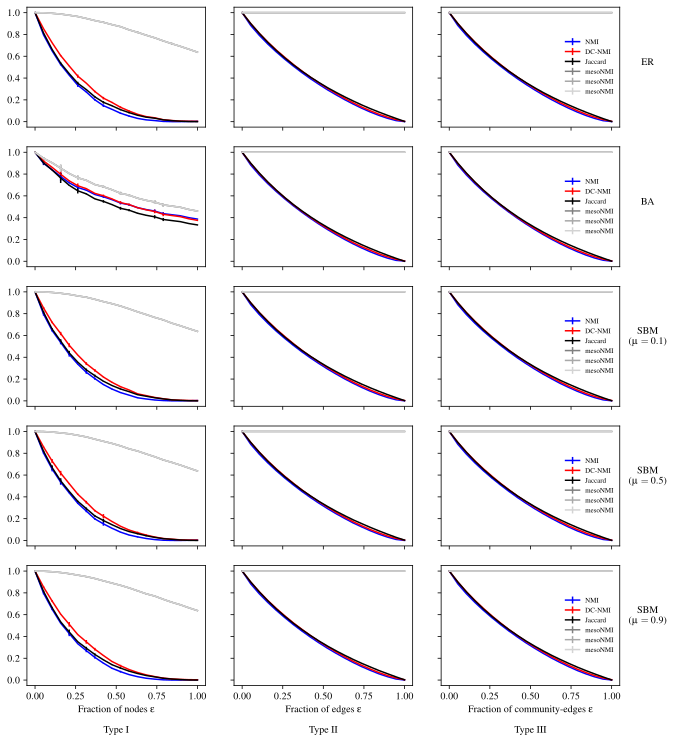

In [24]:
N = 1000 # nodes
num_sims = 2 # simulations
epsilons = np.linspace(0., 1., 20) # noise
Bs = [2,2,2,2,10,100] # partitions

sim_names = ['graphNMI','graphDCNMI','jaccard','mesoNMI','mesoNMI','mesoNMI']
noise_types = ['typeI','typeII','typeIII']
graph_types = ['ER','BA','SBM_eta_0.1','SBM_eta_0.5','SBM_eta_0.9']
colors = ['blue','red','black','gray','#A9A9A9','#D3D3D3']
labels = ['NMI', 'DC-NMI', 'Jaccard', 'mesoNMI', 'mesoNMI', 'mesoNMI']

fig, ax = plt.subplots(5, 3, figsize=(9, 10), sharex=True, sharey=True)
fig.tight_layout()

for row in range(5):
    graph_type = graph_types[row]
    G = gen_graph_type(graph_type, N) # generate the graph we want
    print(f"\n{graph_type}\n")        # print statement so that we know where we are

    # generate partitions
    partitions = [np.zeros(N).astype('int') for _ in Bs] # trivial partition
    #partitions = [np.array(fit_sbm(gtgraph_Gset(G),B)) for B in Bs]
    
    # start noise attack
    for column in range(3):
        noise_type = noise_types[column]
        if noise_type in ['typeI', 'typeII']:
            print(f"attacking {graph_type} with noise {noise_type} . . .")
            noisy_graphs = [[eval(noise_type)(G,eps=eps) for _ in range(num_sims)] for eps in epsilons]
        else:
            print(f"attacking {graph_type} with noise {noise_type}. . .")
            noisy_graphs = [[eval(noise_type)(G,partitions[curve],eps=eps) for _ in range(num_sims)] for eps in epsilons] #or could be 'exec', cant remember.
        
        # start similarity measures
        for curve in range(6):
            sim_name = sim_names[curve]
            sim_measure = sim_name
            color = colors[curve]
            if sim_measure in ['graphNMI','graphDCNMI','jaccard']:
                print(f"computing {sim_measure} . . .")
                means = [np.mean([eval(sim_measure)(G,Gnoisy) for Gnoisy in samples]) for samples in noisy_graphs]
                errors = [3*np.std([eval(sim_measure)(G,Gnoisy) for Gnoisy in samples])/np.sqrt(len(samples)) for samples in noisy_graphs]
            else:
                print(f"computing {sim_measure} . . .")
                means = [np.mean([eval(sim_measure)(G,Gnoisy,partition=partitions[curve]) for Gnoisy in samples]) for samples in noisy_graphs]
                errors = [3*np.std([eval(sim_measure)(G,Gnoisy,partition=partitions[curve]) for Gnoisy in samples])/np.sqrt(len(samples)) for samples in noisy_graphs]

            # plot
            label_name = labels[curve]
            ax[row, column].errorbar(x=epsilons, y=means, yerr=errors, label=label_name, color=color)

            if row==4 and column==0:
                ax[row,column].set_xlabel(f'Fraction of nodes $\epsilon$\n\nType I')
            if row==4 and column==1:
                ax[row,column].set_xlabel(f'Fraction of edges $\epsilon$\n\nType II')
            if row==4 and column==2:
                ax[row,column].set_xlabel(f'Fraction of community-edges $\epsilon$\n\nType III')

            if row==0 and column==2:
                ax[row,column].set_ylabel(f"ER", rotation=0, labelpad=-210)
                ax[row,column].legend(fontsize='7', frameon=False)
            if row==1 and column==2:
                ax[row,column].set_ylabel(f"BA", rotation=0, labelpad=-210)
                ax[row,column].legend(fontsize='7', frameon=False)
            if row==2 and column==2:
                ax[row,column].set_ylabel(f"SBM\n($\mu=0.1$)", rotation=0, labelpad=-210)
                ax[row,column].legend(fontsize='7', frameon=False)
            if row==3 and column==2:
                ax[row,column].set_ylabel(f"SBM\n($\mu=0.5$)", rotation=0, labelpad=-210)
                ax[row,column].legend(fontsize='7', frameon=False)
            if row==4 and column==2:
                ax[row,column].set_ylabel(f"SBM\n($\mu=0.9$)", rotation=0, labelpad=-210)
                ax[row,column].legend(fontsize='7', frameon=False)

plt.savefig("panel_trivial_partition_gt_N1000.pdf", bbox_inches="tight");